### 1. Importación de TensorFlow
Carga del framework principal para deep learning.

In [42]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras import layers, models
from keras.applications import EfficientNetB0
from keras.applications.efficientnet import preprocess_input

### 2. Definición de Clases del Cultivo
Establecimiento de las etiquetas correspondientes a las categorías de enfermedades y estado del maíz.

In [43]:
class_names = [
    'Cercospora',
    'Roya',
    'Tizón',
    'Sana'
]

### 3. Carga del Modelo Base EfficientNetB0
Inicialización del modelo preentrenado como extractor de características base.

In [44]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

### 4. Congelamiento de Capas Base
Desactivación del entrenamiento de los pesos base (	rainable = False) para preservar las características aprendidas en ImageNet.

In [45]:
base_model.trainable = False

### 5. Carga del Clasificador Preentrenado
Lectura del modelo o pesos clasificados previamente almacenados en disco.

In [46]:
classifier = tf.keras.models.load_model(
    'mejor_modelo_maiz.keras'
)

classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 352)            │       450,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,412 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,356,974 (5.18 MB)

 Trainable params: 452,324 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 904,650 (3.45 MB)

### 6. Construcción de Capas de Entrada
Definición de la forma de entrada (input_shape) para las imágenes de 224x224x3.

In [47]:
inputs = layers.Input(shape=(224,224,3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

outputs = classifier(x)

### 7. Ensamblaje del Modelo Final
Integración del extractor de características y las capas densas de clasificación en el modelo definitivo.

In [48]:
final_model = models.Model(inputs, outputs)

final_model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 4)              │       452,324 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,501,895 (17.17 MB)

 Trainable params: 452,324 (1.73 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 8. Función de Predicción e Inferencia
Definición de la función predict_image para cargar, preprocesar y clasificar nuevas imágenes de cultivos de maíz.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


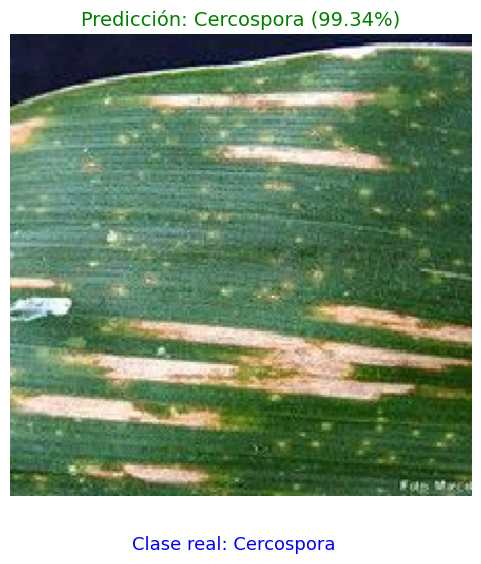

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


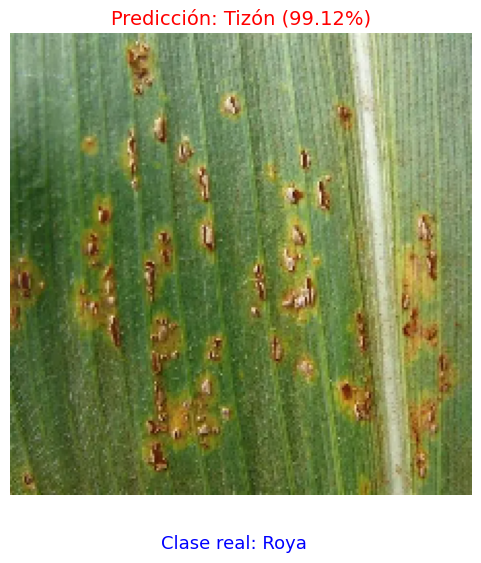

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


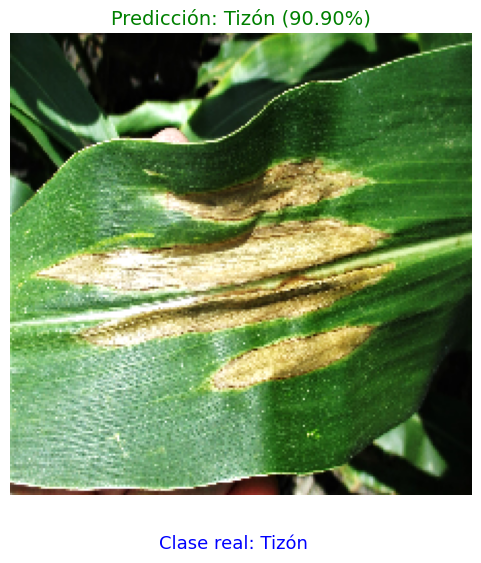

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


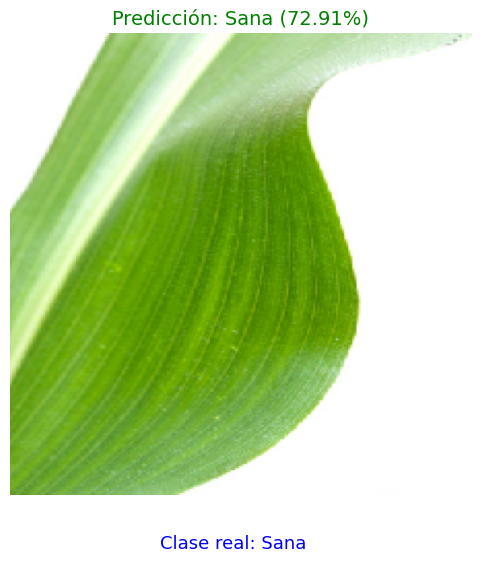

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


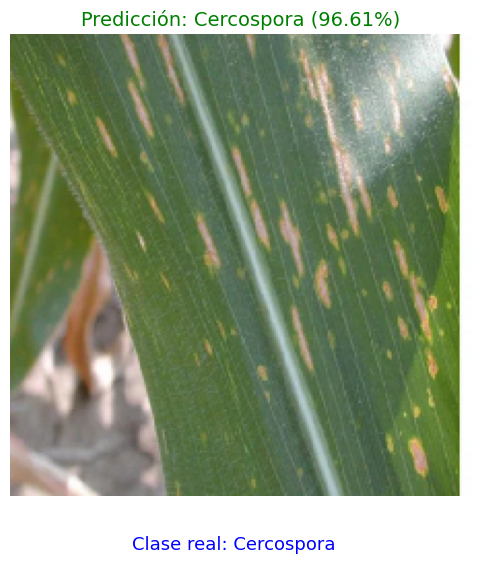

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


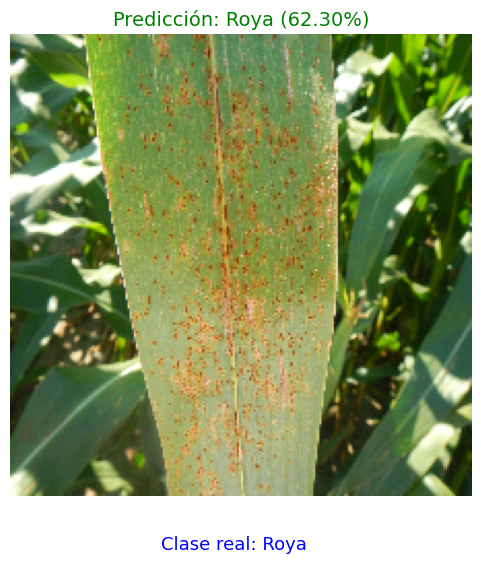

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


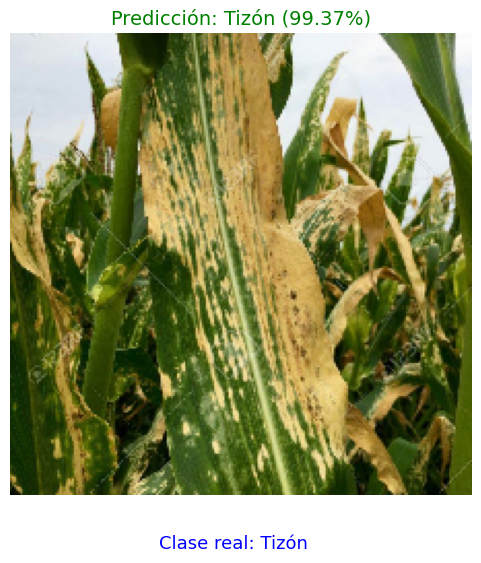

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


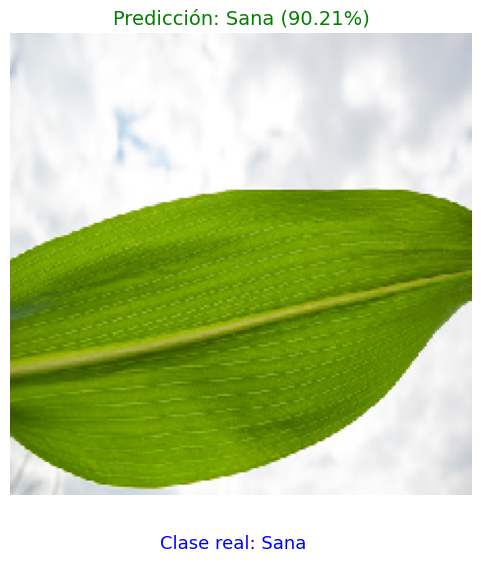

In [ ]:
def predict_image(image_path,real_class):

    # Cargar imagen
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224,224)
    )
    img_display = np.array(img).astype("uint8")
    # Convertir a array
    img_array = tf.keras.utils.img_to_array(img)

    # Batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predicción
    predictions = final_model.predict(img_array)

    predicted_class = np.argmax(predictions)

    confidence = np.max(predictions)

    predicted_label = class_names[predicted_class]

    plt.figure(figsize=(6,6))

    plt.imshow(img_display)

    plt.axis('off')

    color = ''
    if predicted_label == real_class:
        color = 'green'
    else:
        color = 'red'
    # Título verde
    plt.title(
        f"Predicción: {predicted_label} ({confidence*100:.2f}%)",
        color=color,
        fontsize=14
    )

    # Texto rojo abajo
    plt.figtext(
    0.5,               # posición horizontal
    0.02,              # posición vertical
    f"Clase real: {real_class}",
    ha='center',
    color='blue',
    fontsize=13
)

    plt.show()
    plt.close()



predict_image('...\\Imagenes_prueba\\C1.jpg','Cercospora')
predict_image('...\\Imagenes_prueba\\R1.webp','Roya')
predict_image('...\\Imagenes_prueba\\T1.webp','Tizón')
predict_image('...\\Imagenes_prueba\\S1.jpg','Sana')
predict_image('...\\Imagenes_prueba\\C2.webp','Cercospora')
predict_image('...\\Imagenes_prueba\\R2.jpg','Roya')
predict_image('...\\Imagenes_prueba\\T2.jpg','Tizón')
predict_image('...\\Imagenes_prueba\\S2.jpg','Sana')